In [1]:
import h5py
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags, savgol_filter
from scipy.spatial.transform import Rotation

In [2]:
computed_drags_path = Path('drag.npy')
data_path = Path('/data/andreaferrario/ns_data/Freq4.5_a')
dragsim_data_path = Path('/data/andreaferrario/ns_data/Freq4.5_adrag')

In [3]:
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 16,
})

In [4]:
def _fill_nans_1d(series: np.ndarray) -> np.ndarray:
    series = np.asarray(series, dtype=float)
    finite = np.isfinite(series)
    if finite.all():
        return series
    if not finite.any():
        return np.full_like(series, np.nan)
    idx = np.arange(series.size)
    return np.interp(idx, idx[finite], series[finite])


def _safe_savgol_window(length: int, target: int = 101, polyorder: int = 3) -> int:
    window = min(target, length if length % 2 == 1 else length - 1)
    if window <= polyorder:
        window = polyorder + 2 if (polyorder + 2) % 2 == 1 else polyorder + 1
    if window >= length:
        window = length - 1 if length % 2 == 0 else length
    if window % 2 == 0:
        window -= 1
    if window <= polyorder:
        raise ValueError(f"Need at least {polyorder + 2} samples for Savitzky-Golay smoothing, got {length}.")
    return window


def _lag_and_peak_corr(
    force_series: np.ndarray,
    velocity_series: np.ndarray,
    max_abs_lag: int | None = None,
) -> tuple[int, float]:
    force_centered = force_series - np.mean(force_series)
    velocity_centered = velocity_series - np.mean(velocity_series)
    if np.allclose(force_centered, 0.0) or np.allclose(velocity_centered, 0.0):
        return 0, np.nan
    corr = correlate(force_centered, velocity_centered, mode='full', method='auto')
    lags = correlation_lags(force_centered.size, velocity_centered.size, mode='full')
    if max_abs_lag is not None:
        # Restrict the search to |lag| < max_abs_lag.
        lag_mask = np.abs(lags) < int(max_abs_lag)
        if np.any(lag_mask):
            corr = corr[lag_mask]
            lags = lags[lag_mask]
    best = int(np.argmax(corr))
    norm = np.linalg.norm(force_centered) * np.linalg.norm(velocity_centered)
    peak_corr = float(corr[best] / norm) if norm > 0 else np.nan
    return int(lags[best]), peak_corr


def _shift_earlier(series: np.ndarray, lag: int) -> np.ndarray:
    shifted = np.full_like(series, np.nan)
    if lag > 0:
        shifted[:-lag] = series[lag:]
    elif lag < 0:
        shifted[-lag:] = series[:lag]
    else:
        shifted[:] = series
    return shifted


def _dominant_period_samples(series: np.ndarray) -> float:
    centered = series - np.mean(series)
    if np.allclose(centered, 0.0):
        return np.nan
    spectrum = np.fft.rfft(centered)
    power = np.abs(spectrum) ** 2
    if power.size <= 2:
        return np.nan
    power[0] = 0.0
    peak = int(np.argmax(power))
    if peak <= 0:
        return np.nan
    return centered.size / peak

In [5]:
h5_path = data_path / 'drags.h5'
sim_path = data_path / 'output' / 'simulation.hdf5'
if not h5_path.exists():
    raise FileNotFoundError(f'{h5_path} not found')
if not sim_path.exists():
    raise FileNotFoundError(f'{sim_path} not found')


## Compute equivalent drag spine

In [6]:
skip = 1000  # skip
end = 3000

with h5py.File(h5_path, 'r') as f_drag, h5py.File(sim_path, 'r') as f_sim:
    pressure_drags = np.array(f_drag['pressure_drags'])
    pressure_torques = np.array(f_drag['pressure_torques'])

    links_grp = f_sim['FARMSLISTanimats']['0']['sensors']['links']
    link_array = np.array(links_grp['array'])
    raw_names = np.array(links_grp['names'])

link_names = [
    name.decode('utf-8') if isinstance(name, (bytes, bytearray)) else str(name)
    for name in raw_names.tolist()
]

selected_link_mask = np.array(
    [
        (
            name.startswith('link_body_') and not name.endswith('_z')
        )
        or (
            name.startswith('link_leg_')
            and not (name.endswith('_z') or name.endswith('_x') or name.endswith('_y'))
        )
        for name in link_names
    ],
    dtype=bool,
)
selected_link_names = [name for name, keep in zip(link_names, selected_link_mask) if keep]
if len(selected_link_names) != 52:
    raise ValueError(f'Expected 52 filtered links, got {len(selected_link_names)}.')

# slice out transient steps and keep only the 52 dynamic body/leg links
link_array = link_array[skip:end, selected_link_mask]
link_names = selected_link_names

# link_array has shape (timestep, n_links, 20); indices 10:14 store the world
# orientation quaternion (x, y, z, w) for each link.
link_quats = link_array[:, :, 10:14]

# link_array also stores linear velocity x/y/z in 14:17 and angular velocity x/y/z
# in 17:20.
linear_velocity_world = link_array[:, :, -6:-3]
angular_velocity_world = link_array[:, :, -3:]

# drags.h5 already stores only the 52 dynamic links, transposed to match
# the sensor time axis before computing axiswise drag coefficients.
pressure_drags_world_t = pressure_drags.transpose(2, 0, 1)[skip:end]
pressure_torques_world_t = pressure_torques.transpose(2, 0, 1)[skip:end]

quat_norm = np.linalg.norm(link_quats, axis=2, keepdims=True)
valid_quats = np.all(np.isfinite(link_quats), axis=2) & (quat_norm[..., 0] > 1.0e-12)

# The simulator uses q * v * q^* to rotate a local vector into the world frame.
# To go from world -> local, use the inverse rotation.
rotation = Rotation.from_quat(link_quats / quat_norm)
rotation_inv = rotation.inv()

linear_velocity_local = np.full_like(linear_velocity_world, np.nan, dtype=float)
angular_velocity_local = np.full_like(angular_velocity_world, np.nan, dtype=float)
pressure_drags_local_t = np.full_like(pressure_drags_world_t, np.nan, dtype=float)
pressure_torques_local_t = np.full_like(pressure_torques_world_t, np.nan, dtype=float)

if np.any(valid_quats):
    linear_velocity_local[valid_quats] = rotation_inv[valid_quats].apply(linear_velocity_world[valid_quats])
    angular_velocity_local[valid_quats] = rotation_inv[valid_quats].apply(angular_velocity_world[valid_quats])
    pressure_drags_local_t[valid_quats] = rotation_inv[valid_quats].apply(pressure_drags_world_t[valid_quats])
    pressure_torques_local_t[valid_quats] = rotation_inv[valid_quats].apply(pressure_torques_world_t[valid_quats])

linear_denom = linear_velocity_local * np.abs(linear_velocity_local)
angular_denom = angular_velocity_local * np.abs(angular_velocity_local)

with np.errstate(divide='ignore', invalid='ignore'):
    linear_coeffs_t = np.divide(
        -pressure_drags_local_t,
        linear_denom,
        out=np.full_like(pressure_drags_local_t, np.nan, dtype=float),
        where=linear_denom != 0,
    )
    angular_coeffs_t = np.divide(
        -pressure_torques_local_t,
        angular_denom,
        out=np.full_like(pressure_torques_local_t, np.nan, dtype=float),
        where=angular_denom != 0,
    )

drag_coeffs_t = np.concatenate([linear_coeffs_t, angular_coeffs_t], axis=2)
valid_counts = np.isfinite(drag_coeffs_t).sum(axis=0)
valid_sums = np.nansum(drag_coeffs_t, axis=0)
drag_coeffs_mean = np.divide(
    valid_sums,
    valid_counts,
    out=np.full((drag_coeffs_t.shape[1], drag_coeffs_t.shape[2]), np.nan, dtype=float),
    where=valid_counts != 0,
)

print('filtered link count:', len(selected_link_names))
print('per-step local coefficients shape:', drag_coeffs_t.shape)
print('mean coefficients shape:', drag_coeffs_mean.shape)

filtered link count: 52
per-step local coefficients shape: (2000, 52, 6)
mean coefficients shape: (52, 6)


In [7]:
link_count = min(40, pressure_drags_local_t.shape[1])
link_ids = np.arange(1, link_count + 1)
#swim cycle 0.218s

# consider linear x, linear y, and rotational z components
x_drag = pressure_drags_local_t[:, :link_count, 0]
y_drag = pressure_drags_local_t[:, :link_count, 1]
rz_torque = pressure_torques_local_t[:, :link_count, 2]

x_velocity = linear_velocity_local[:, :link_count, 0]
y_velocity = linear_velocity_local[:, :link_count, 1]
rz_omega = angular_velocity_local[:, :link_count, 2]

window_length = _safe_savgol_window(x_drag.shape[0], target=101, polyorder=3)
polyorder = 3

x_drag_filled = np.column_stack([_fill_nans_1d(x_drag[:, i]) for i in range(link_count)])
y_drag_filled = np.column_stack([_fill_nans_1d(y_drag[:, i]) for i in range(link_count)])
rz_torque_filled = np.column_stack([_fill_nans_1d(rz_torque[:, i]) for i in range(link_count)])

x_velocity_filled = np.column_stack([_fill_nans_1d(x_velocity[:, i]) for i in range(link_count)])
y_velocity_filled = np.column_stack([_fill_nans_1d(y_velocity[:, i]) for i in range(link_count)])
rz_omega_filled = np.column_stack([_fill_nans_1d(rz_omega[:, i]) for i in range(link_count)])

smoothed_x = savgol_filter(
    x_drag_filled,
    window_length=window_length,
    polyorder=polyorder,
    axis=0,
    mode='interp',
)
smoothed_y = savgol_filter(
    y_drag_filled,
    window_length=window_length,
    polyorder=polyorder,
    axis=0,
    mode='interp',
)
smoothed_rz = savgol_filter(
    rz_torque_filled,
    window_length=window_length,
    polyorder=polyorder,
    axis=0,
    mode='interp',
)

# Align the y force profile to the y velocity using a small lag search,
# then keep only the high-amplitude part of the cycle when computing C_D.
max_abs_lag_samples = 200
active_fraction = 0.3
x_drag_mask = np.zeros_like(smoothed_x, dtype=bool)
aligned_y_drag = np.full_like(smoothed_y, np.nan, dtype=float)
aligned_y_drag_mask = np.zeros_like(smoothed_y, dtype=bool)
aligned_rz_drag = np.full_like(smoothed_rz, np.nan, dtype=float)
aligned_rz_drag_mask = np.zeros_like(smoothed_rz, dtype=bool)
y_force_lags = np.zeros(link_count, dtype=int)
y_force_peak_corrs = np.full(link_count, np.nan, dtype=float)
rz_force_lags = np.zeros(link_count, dtype=int)
rz_force_peak_corrs = np.full(link_count, np.nan, dtype=float)

for i in range(link_count):
    lag_i, peak_corr = _lag_and_peak_corr(
        smoothed_y[:, i],
        -y_velocity_filled[:, i],
        max_abs_lag=max_abs_lag_samples,
    )
    y_force_lags[i] = lag_i
    y_force_peak_corrs[i] = peak_corr

    aligned_force = _shift_earlier(smoothed_y[:, i], lag_i)
    aligned_y_drag[:, i] = aligned_force

    finite_force = np.isfinite(aligned_force)
    finite_velocity = np.isfinite(y_velocity_filled[:, i])
    if not np.any(finite_force) or not np.any(finite_velocity):
        continue

    force_max = np.max(np.abs(aligned_force[finite_force]))
    velocity_max = np.max(np.abs(y_velocity_filled[finite_velocity, i]))
    if force_max <= 0 or velocity_max <= 0:
        continue

    opposite_sign_mask = aligned_force * y_velocity_filled[:, i] < 0
    aligned_y_drag_mask[:, i] = (
        finite_force
        & finite_velocity
        & (np.abs(aligned_force) >= active_fraction * force_max)
        & (np.abs(y_velocity_filled[:, i]) >= active_fraction * velocity_max)
        & opposite_sign_mask
    )

    finite_x_force = np.isfinite(smoothed_x[:, i])
    finite_x_velocity = np.isfinite(x_velocity_filled[:, i])
    if np.any(finite_x_force) and np.any(finite_x_velocity):
        x_force_max = np.max(np.abs(smoothed_x[finite_x_force, i]))
        x_velocity_max = np.max(np.abs(x_velocity_filled[finite_x_velocity, i]))
        if x_force_max > 0 and x_velocity_max > 0:
            x_opposite_sign_mask = smoothed_x[:, i] * x_velocity_filled[:, i] < 0
            x_drag_mask[:, i] = (
                finite_x_force
                & finite_x_velocity
                & (np.abs(smoothed_x[:, i]) >= active_fraction * x_force_max)
                & (np.abs(x_velocity_filled[:, i]) >= active_fraction * x_velocity_max)
                & x_opposite_sign_mask
            )

    lag_rz_i, peak_corr_rz = _lag_and_peak_corr(
        smoothed_rz[:, i],
        -rz_omega_filled[:, i],
        max_abs_lag=max_abs_lag_samples,
    )
    rz_force_lags[i] = lag_rz_i
    rz_force_peak_corrs[i] = peak_corr_rz

    aligned_rz_force = _shift_earlier(smoothed_rz[:, i], lag_rz_i)
    aligned_rz_drag[:, i] = aligned_rz_force

    finite_rz_force = np.isfinite(aligned_rz_force)
    finite_rz_velocity = np.isfinite(rz_omega_filled[:, i])
    if not np.any(finite_rz_force) or not np.any(finite_rz_velocity):
        continue

    rz_force_max = np.max(np.abs(aligned_rz_force[finite_rz_force]))
    rz_velocity_max = np.max(np.abs(rz_omega_filled[finite_rz_velocity, i]))
    if rz_force_max <= 0 or rz_velocity_max <= 0:
        continue

    rz_opposite_sign_mask = aligned_rz_force * rz_omega_filled[:, i] < 0
    aligned_rz_drag_mask[:, i] = (
        finite_rz_force
        & finite_rz_velocity
        & (np.abs(aligned_rz_force) >= active_fraction * rz_force_max)
        & (np.abs(rz_omega_filled[:, i]) >= active_fraction * rz_velocity_max)
        & rz_opposite_sign_mask
    )

# compute coefficients C_D for each component using same denom style
drag_denom_x = x_velocity_filled * np.abs(x_velocity_filled)
drag_denom_y = y_velocity_filled * np.abs(y_velocity_filled)
rot_denom_rz = rz_omega_filled * np.abs(rz_omega_filled)
with np.errstate(divide='ignore', invalid='ignore'):
    drag_coeff_smoothed_x = np.divide(
        smoothed_x,
        drag_denom_x,
        out=np.full_like(smoothed_x, np.nan),
        where=x_drag_mask & (drag_denom_x != 0),
    )
    drag_coeff_smoothed_y = np.divide(
        aligned_y_drag,
        drag_denom_y,
        out=np.full_like(aligned_y_drag, np.nan, dtype=float),
        where=aligned_y_drag_mask & (drag_denom_y != 0),
    )
    drag_coeff_smoothed_rz = np.divide(
        aligned_rz_drag,
        rot_denom_rz,
        out=np.full_like(smoothed_rz, np.nan),
        where=aligned_rz_drag_mask & (rot_denom_rz != 0),
    )

drag_coeff_mean_smoothed_x = np.nanmean(drag_coeff_smoothed_x, axis=0)
drag_coeff_mean_smoothed_y = np.nanmean(drag_coeff_smoothed_y, axis=0)
drag_coeff_mean_smoothed_rz = np.nanmean(drag_coeff_smoothed_rz, axis=0)

print(f'Analyzed the first {link_count} links in the local x,y,rz directions.')
print(f'Savitzky-Golay window length: {window_length} samples (polyorder={polyorder}).')
print(f'Y-force lag search limited to |lag| < {max_abs_lag_samples} samples.')
print(f'Median y-force lag: {np.nanmedian(y_force_lags):.1f} samples')
print(f'Median y-force correlation: {np.nanmedian(y_force_peak_corrs):.3f}')
print(f'Median rz-force lag: {np.nanmedian(rz_force_lags):.1f} samples')
print(f'Median rz-force correlation: {np.nanmedian(rz_force_peak_corrs):.3f}')
print(f'Fraction of samples kept for y drag: {aligned_y_drag_mask.mean():.3f}')
print(f'Fraction of samples kept for rz drag: {aligned_rz_drag_mask.mean():.3f}')
print(f'Median mean C_D (smoothed x): {np.nanmedian(drag_coeff_mean_smoothed_x):.3f}')
print(f'Median mean C_D (smoothed y): {np.nanmedian(drag_coeff_mean_smoothed_y):.3f}')
print(f'Median mean C_D (smoothed rz): {np.nanmedian(drag_coeff_mean_smoothed_rz):.3f}')

Analyzed the first 40 links in the local x,y,rz directions.
Savitzky-Golay window length: 101 samples (polyorder=3).
Y-force lag search limited to |lag| < 200 samples.
Median y-force lag: -49.5 samples
Median y-force correlation: 0.974
Median rz-force lag: -2.5 samples
Median rz-force correlation: 0.932
Fraction of samples kept for y drag: 0.661
Fraction of samples kept for rz drag: 0.655
Median mean C_D (smoothed x): -0.002
Median mean C_D (smoothed y): -0.193
Median mean C_D (smoothed rz): -0.000


/tmp/ipykernel_1961456/3994648188.py:161: RuntimeWarning: Mean of empty slice
  drag_coeff_mean_smoothed_x = np.nanmean(drag_coeff_smoothed_x, axis=0)


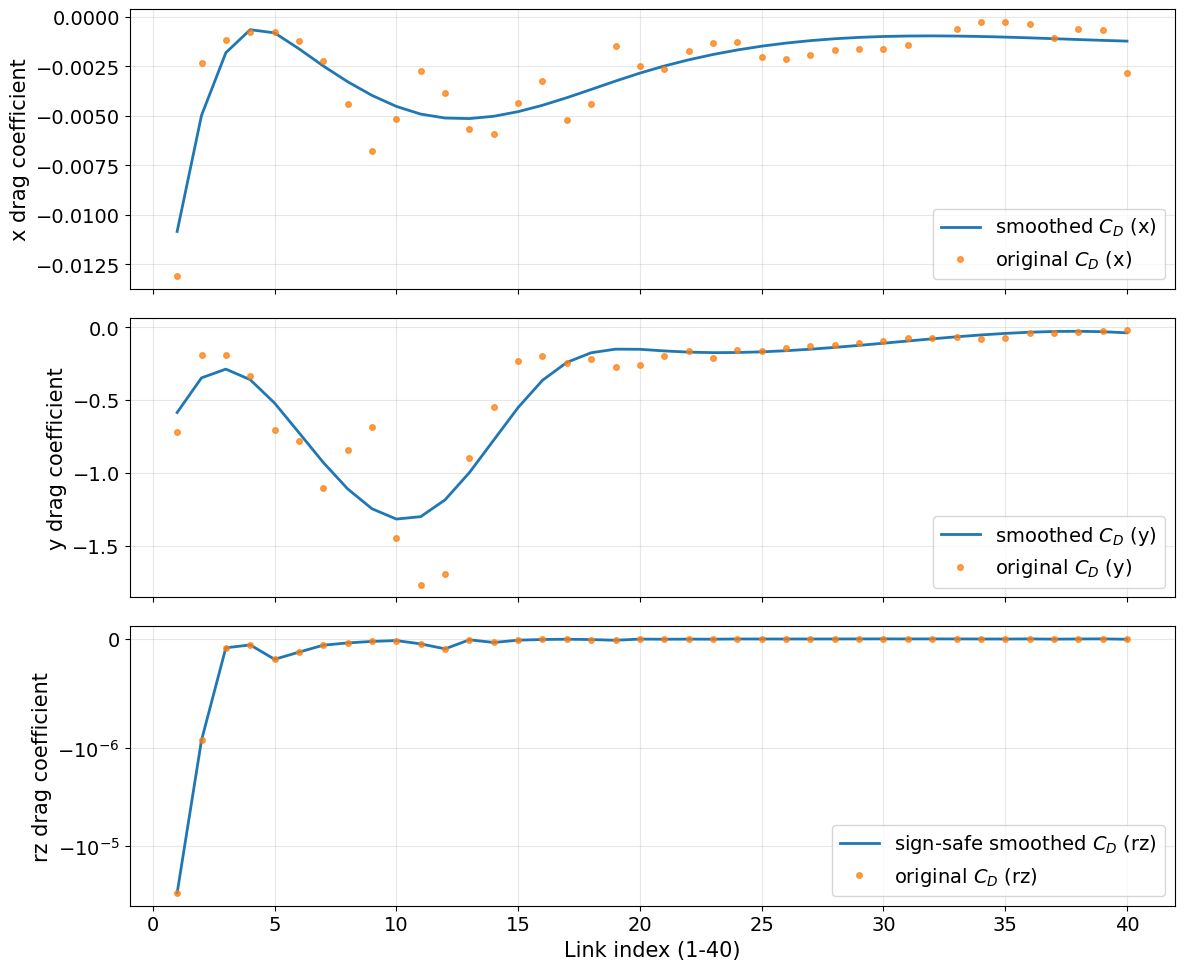

In [8]:
# Plot mean drag coefficient: smoothed line + original dots
fig, (ax_x, ax_y, ax_rz) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

from scipy.interpolate import UnivariateSpline, PchipInterpolator

def _csap_smooth_profile(
    values: np.ndarray,
    smooth_factor: float = 0.20,
    spline_weight: float = 1.0,
    ) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    if finite.sum() < 4:
        return values.copy()

    x = np.arange(values.size, dtype=float)
    x_fit = x[finite]
    y_fit = values[finite]

    y_var = float(np.nanvar(y_fit))
    if not np.isfinite(y_var) or y_var <= 0:
        return values.copy()

    y_interp = np.interp(x, x_fit, y_fit)
    s = smooth_factor * x_fit.size * y_var
    spline = UnivariateSpline(x_fit, y_fit, k=3, s=s)
    y_spline = spline(x)

    w = float(np.clip(spline_weight, 0.0, 1.0))
    return w * y_spline + (1.0 - w) * y_interp

def _rz_sign_safe_smooth(
    values: np.ndarray,
    blend_to_raw: float = 0.55,
    envelope_half_width: int = 4,
    ) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    if finite.sum() < 3:
        return values.copy()

    x = np.arange(values.size, dtype=float)
    x_fit = x[finite]
    y_fit = values[finite]
    y_interp = np.interp(x, x_fit, y_fit)

    # Shape-preserving interpolation avoids cubic overshoot across zero.
    y_pchip = PchipInterpolator(x_fit, y_fit)(x)

    # Clamp within a wider local envelope to keep the curve realistic but still smooth.
    half_w = max(1, int(envelope_half_width))
    lower = np.empty_like(y_interp)
    upper = np.empty_like(y_interp)
    for i in range(y_interp.size):
        lo = max(0, i - half_w)
        hi = min(y_interp.size, i + half_w + 1)
        local = y_interp[lo:hi]
        lower[i] = np.min(local)
        upper[i] = np.max(local)
    y_clamped = np.clip(y_pchip, lower, upper)

    # Near sign flips, blend toward raw data to avoid artificial zero crossing.
    sign_flip = np.zeros_like(y_interp, dtype=bool)
    sign_flip[1:] |= (y_interp[1:] * y_interp[:-1]) <= 0
    sign_flip[:-1] |= (y_interp[1:] * y_interp[:-1]) <= 0

    y_out = y_clamped.copy()
    y_out[sign_flip] = (1.0 - blend_to_raw) * y_clamped[sign_flip] + blend_to_raw * y_interp[sign_flip]
    return y_out

smooth_x = _csap_smooth_profile(drag_coeff_mean_smoothed_x, smooth_factor=0.20, spline_weight=1.0)
smooth_y = _csap_smooth_profile(drag_coeff_mean_smoothed_y, smooth_factor=0.15, spline_weight=1.0)
smooth_rz = _rz_sign_safe_smooth(drag_coeff_mean_smoothed_rz, blend_to_raw=0.25, envelope_half_width=4)

# Shared smoothed mean coefficients for downstream plotting/export cells.
drag_coeff_mean_smoothed_plot_x = smooth_x.copy()
drag_coeff_mean_smoothed_plot_y = smooth_y.copy()
drag_coeff_mean_smoothed_plot_rz = smooth_rz.copy()

ax_x.plot(link_ids, drag_coeff_mean_smoothed_plot_x, label='smoothed $C_D$ (x)', linewidth=2.0)
ax_x.plot(link_ids, drag_coeff_mean_smoothed_x, linestyle='None', marker='o', markersize=4, alpha=0.75, label='original $C_D$ (x)')
ax_x.set_ylabel('x drag coefficient')
ax_x.grid(True, alpha=0.3)
ax_x.legend(loc='lower right')

ax_y.plot(link_ids, drag_coeff_mean_smoothed_plot_y, label='smoothed $C_D$ (y)', linewidth=2.0)
ax_y.plot(link_ids, drag_coeff_mean_smoothed_y, linestyle='None', marker='o', markersize=4, alpha=0.75, label='original $C_D$ (y)')
ax_y.set_ylabel('y drag coefficient')
ax_y.grid(True, alpha=0.3)
ax_y.legend(loc='lower right')

ax_rz.plot(link_ids, drag_coeff_mean_smoothed_plot_rz, label='sign-safe smoothed $C_D$ (rz)', linewidth=2.0)
ax_rz.plot(link_ids, drag_coeff_mean_smoothed_rz, linestyle='None', marker='o', markersize=4, alpha=0.75, label='original $C_D$ (rz)')
ax_rz.set_ylabel('rz drag coefficient')
ax_rz.set_yscale('symlog', linthresh=1e-6)
ax_rz.set_xlabel('Link index (1-40)')
ax_rz.grid(True, alpha=0.3)
ax_rz.legend(loc='lower right')

fig.tight_layout()

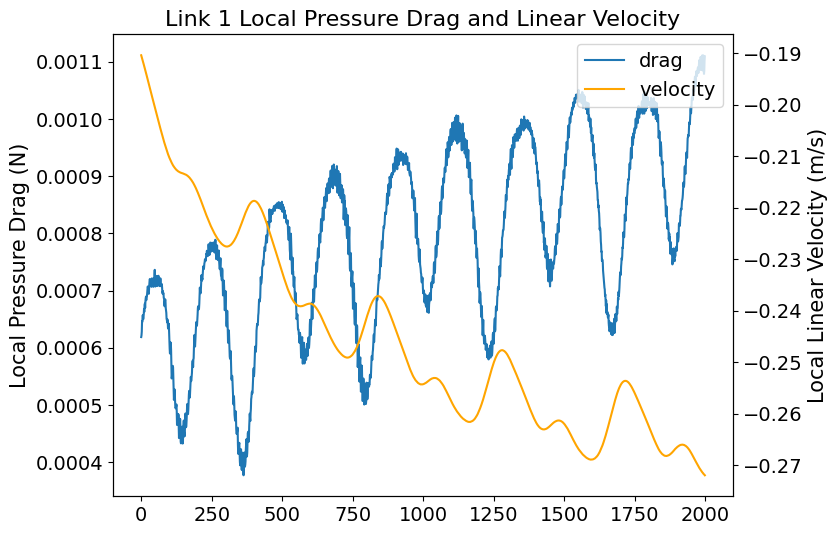

In [9]:
fig, ax1 = plt.subplots(figsize=(8, 6))
idx = 0
# First y-axis
ax1.plot(pressure_drags_local_t[:, idx, 0], color='tab:blue', label='drag')
ax1.set_ylabel('Local Pressure Drag (N)')

# Second y-axis
ax2 = ax1.twinx()
ax2.plot(x_velocity[:, idx], color='orange', label='velocity')
ax2.set_ylabel('Local Linear Velocity (m/s)')
plt.title(f'Link {idx + 1} Local Pressure Drag and Linear Velocity')
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')
plt.show()

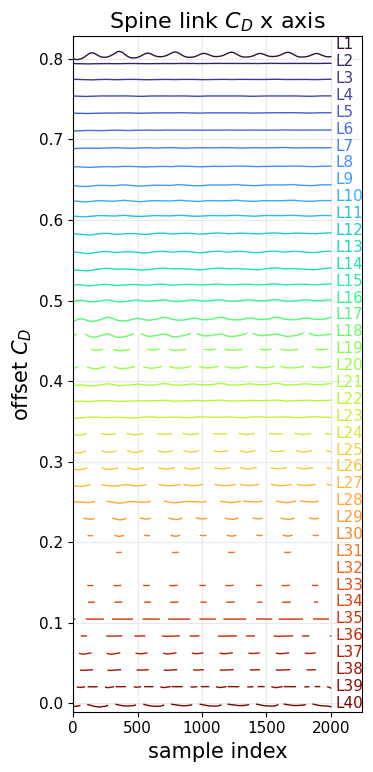

In [10]:
n_spine_links = min(40, drag_coeff_smoothed_x.shape[1])
sample_index = np.arange(drag_coeff_smoothed_x.shape[0])

fig, ax = plt.subplots(figsize=(4, 8))
cmap = plt.get_cmap('turbo', max(n_spine_links, 2))

valid_values = drag_coeff_smoothed_x[:, :n_spine_links]
finite_values = valid_values[np.isfinite(valid_values)]
if finite_values.size == 0:
    raise ValueError('No finite values found in drag_coeff_smoothed_x.')

value_span = float(np.nanmax(finite_values) - np.nanmin(finite_values))
offset_step = 1.15 * value_span if value_span > 0 else 1.0
vertical_offsets = np.arange(n_spine_links)[::-1] * offset_step

for i in range(n_spine_links):
    color = cmap(i)
    trace = drag_coeff_smoothed_x[:, i] + vertical_offsets[i]
    ax.plot(sample_index, trace, color=color, linewidth=1.0)
    ax.text(
        sample_index[-1] + 40,
        vertical_offsets[i],
        f'L{i + 1}',
        va='center',
        ha='left',
        fontsize=11,
        color=color,
    )

ax.set_xlabel('sample index')
ax.set_ylabel('offset $C_D$')
ax.set_title('Spine link $C_D$ x axis')
ax.grid(True, alpha=0.25)
ax.set_xlim(sample_index[0], sample_index[-1] + 240)
ax.set_ylim(-0.5 * offset_step, vertical_offsets[0] + 0.5 * offset_step)
ax.tick_params(labelsize=11)
fig.tight_layout()

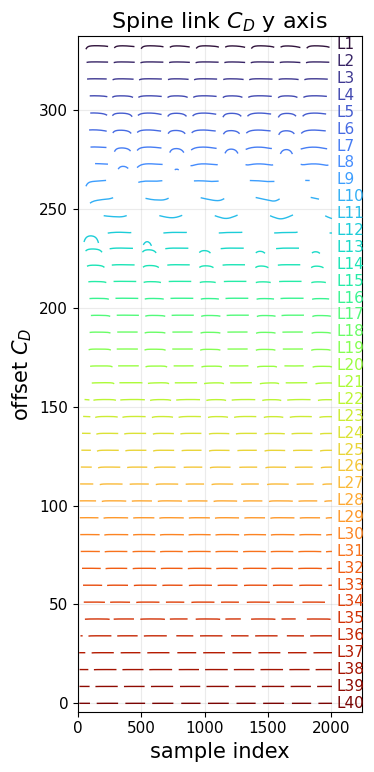

In [11]:
n_spine_links = min(40, drag_coeff_smoothed_y.shape[1])
sample_index = np.arange(drag_coeff_smoothed_y.shape[0])

fig, ax = plt.subplots(figsize=(4, 8))
cmap = plt.get_cmap('turbo', max(n_spine_links, 2))

valid_values = drag_coeff_smoothed_y[:, :n_spine_links]
finite_values = valid_values[np.isfinite(valid_values)]
if finite_values.size == 0:
    raise ValueError('No finite values found in drag_coeff_smoothed_y.')

value_span = float(np.nanmax(finite_values) - np.nanmin(finite_values))
offset_step = 1.15 * value_span if value_span > 0 else 1.0
vertical_offsets = np.arange(n_spine_links)[::-1] * offset_step

for i in range(n_spine_links):
    color = cmap(i)
    trace = drag_coeff_smoothed_y[:, i] + vertical_offsets[i]
    ax.plot(sample_index, trace, color=color, linewidth=1.0)
    ax.text(
        sample_index[-1] + 40,
        vertical_offsets[i],
        f'L{i + 1}',
        va='center',
        ha='left',
        fontsize=11,
        color=color,
    )

ax.set_xlabel('sample index')
ax.set_ylabel('offset $C_D$')
ax.set_title('Spine link $C_D$ y axis')
ax.grid(True, alpha=0.25)
ax.set_xlim(sample_index[0], sample_index[-1] + 240)
ax.set_ylim(-0.5 * offset_step, vertical_offsets[0] + 0.5 * offset_step)
ax.tick_params(labelsize=11)
fig.tight_layout()

## Compute equivalent drag limb

In [12]:
limb_link_count = 12
limb_link_start = pressure_drags_local_t.shape[1] - limb_link_count
limb_link_ids = np.arange(limb_link_start + 1, pressure_drags_local_t.shape[1] + 1)

x_drag_limb = pressure_drags_local_t[:, limb_link_start:, 0]
y_drag_limb = pressure_drags_local_t[:, limb_link_start:, 1]
rz_torque_limb = pressure_torques_local_t[:, limb_link_start:, 2]

x_velocity_limb = linear_velocity_local[:, limb_link_start:, 0]
y_velocity_limb = linear_velocity_local[:, limb_link_start:, 1]
rz_omega_limb = angular_velocity_local[:, limb_link_start:, 2]

x_drag_limb_filled = np.column_stack([_fill_nans_1d(x_drag_limb[:, i]) for i in range(limb_link_count)])
y_drag_limb_filled = np.column_stack([_fill_nans_1d(y_drag_limb[:, i]) for i in range(limb_link_count)])
rz_torque_limb_filled = np.column_stack([_fill_nans_1d(rz_torque_limb[:, i]) for i in range(limb_link_count)])

x_velocity_limb_filled = np.column_stack([_fill_nans_1d(x_velocity_limb[:, i]) for i in range(limb_link_count)])
y_velocity_limb_filled = np.column_stack([_fill_nans_1d(y_velocity_limb[:, i]) for i in range(limb_link_count)])
rz_omega_limb_filled = np.column_stack([_fill_nans_1d(rz_omega_limb[:, i]) for i in range(limb_link_count)])

smoothed_x_limb = savgol_filter(
    x_drag_limb_filled,
    window_length=window_length,
    polyorder=polyorder,
    axis=0,
    mode='interp',
)
smoothed_y_limb = savgol_filter(
    y_drag_limb_filled,
    window_length=window_length,
    polyorder=polyorder,
    axis=0,
    mode='interp',
)
smoothed_rz_limb = savgol_filter(
    rz_torque_limb_filled,
    window_length=window_length,
    polyorder=polyorder,
    axis=0,
    mode='interp',
)

x_drag_mask_limb = np.zeros_like(smoothed_x_limb, dtype=bool)
aligned_y_drag_limb = np.full_like(smoothed_y_limb, np.nan, dtype=float)
aligned_y_drag_mask_limb = np.zeros_like(smoothed_y_limb, dtype=bool)
aligned_rz_drag_limb = np.full_like(smoothed_rz_limb, np.nan, dtype=float)
aligned_rz_drag_mask_limb = np.zeros_like(smoothed_rz_limb, dtype=bool)

x_force_lags_limb = np.zeros(limb_link_count, dtype=int)
y_force_lags_limb = np.zeros(limb_link_count, dtype=int)
rz_force_lags_limb = np.zeros(limb_link_count, dtype=int)

for i in range(limb_link_count):
    lag_x_i, _ = _lag_and_peak_corr(smoothed_x_limb[:, i], -x_velocity_limb_filled[:, i], max_abs_lag=max_abs_lag_samples)
    x_force_lags_limb[i] = lag_x_i
    aligned_x_force = _shift_earlier(smoothed_x_limb[:, i], lag_x_i)
    finite_x_force = np.isfinite(aligned_x_force)
    finite_x_velocity = np.isfinite(x_velocity_limb_filled[:, i])
    if np.any(finite_x_force) and np.any(finite_x_velocity):
        x_force_max = np.max(np.abs(aligned_x_force[finite_x_force]))
        x_velocity_max = np.max(np.abs(x_velocity_limb_filled[finite_x_velocity, i]))
        if x_force_max > 0 and x_velocity_max > 0:
            x_drag_mask_limb[:, i] = (
                finite_x_force
                & finite_x_velocity
                & (np.abs(aligned_x_force) >= active_fraction * x_force_max)
                & (np.abs(x_velocity_limb_filled[:, i]) >= active_fraction * x_velocity_max)
                & (aligned_x_force * x_velocity_limb_filled[:, i] < 0)
            )

    lag_y_i, _ = _lag_and_peak_corr(smoothed_y_limb[:, i], -y_velocity_limb_filled[:, i], max_abs_lag=max_abs_lag_samples)
    y_force_lags_limb[i] = lag_y_i
    aligned_y_force = _shift_earlier(smoothed_y_limb[:, i], lag_y_i)
    aligned_y_drag_limb[:, i] = aligned_y_force
    finite_y_force = np.isfinite(aligned_y_force)
    finite_y_velocity = np.isfinite(y_velocity_limb_filled[:, i])
    if np.any(finite_y_force) and np.any(finite_y_velocity):
        y_force_max = np.max(np.abs(aligned_y_force[finite_y_force]))
        y_velocity_max = np.max(np.abs(y_velocity_limb_filled[finite_y_velocity, i]))
        if y_force_max > 0 and y_velocity_max > 0:
            aligned_y_drag_mask_limb[:, i] = (
                finite_y_force
                & finite_y_velocity
                & (np.abs(aligned_y_force) >= active_fraction * y_force_max)
                & (np.abs(y_velocity_limb_filled[:, i]) >= active_fraction * y_velocity_max)
                & (aligned_y_force * y_velocity_limb_filled[:, i] < 0)
            )

    lag_rz_i, _ = _lag_and_peak_corr(smoothed_rz_limb[:, i], -rz_omega_limb_filled[:, i], max_abs_lag=max_abs_lag_samples)
    rz_force_lags_limb[i] = lag_rz_i
    aligned_rz_force = _shift_earlier(smoothed_rz_limb[:, i], lag_rz_i)
    aligned_rz_drag_limb[:, i] = aligned_rz_force
    finite_rz_force = np.isfinite(aligned_rz_force)
    finite_rz_velocity = np.isfinite(rz_omega_limb_filled[:, i])
    if np.any(finite_rz_force) and np.any(finite_rz_velocity):
        rz_force_max = np.max(np.abs(aligned_rz_force[finite_rz_force]))
        rz_velocity_max = np.max(np.abs(rz_omega_limb_filled[finite_rz_velocity, i]))
        if rz_force_max > 0 and rz_velocity_max > 0:
            aligned_rz_drag_mask_limb[:, i] = (
                finite_rz_force
                & finite_rz_velocity
                & (np.abs(aligned_rz_force) >= active_fraction * rz_force_max)
                & (np.abs(rz_omega_limb_filled[:, i]) >= active_fraction * rz_velocity_max)
                & (aligned_rz_force * rz_omega_limb_filled[:, i] < 0)
            )

with np.errstate(divide='ignore', invalid='ignore'):
    drag_coeff_smoothed_x_limb = np.divide(
        smoothed_x_limb,
        x_velocity_limb_filled * np.abs(x_velocity_limb_filled),
        out=np.full_like(smoothed_x_limb, np.nan),
        where=x_drag_mask_limb & (x_velocity_limb_filled != 0),
    )
    drag_coeff_smoothed_y_limb = np.divide(
        aligned_y_drag_limb,
        y_velocity_limb_filled * np.abs(y_velocity_limb_filled),
        out=np.full_like(aligned_y_drag_limb, np.nan),
        where=aligned_y_drag_mask_limb & (y_velocity_limb_filled != 0),
    )
    drag_coeff_smoothed_rz_limb = np.divide(
        aligned_rz_drag_limb,
        rz_omega_limb_filled * np.abs(rz_omega_limb_filled),
        out=np.full_like(aligned_rz_drag_limb, np.nan),
        where=aligned_rz_drag_mask_limb & (rz_omega_limb_filled != 0),
    )

limb_drag_coeff_mean_smoothed_x = np.nanmean(drag_coeff_smoothed_x_limb, axis=0)
limb_drag_coeff_mean_smoothed_y = np.nanmean(drag_coeff_smoothed_y_limb, axis=0)
limb_drag_coeff_mean_smoothed_rz = np.nanmean(drag_coeff_smoothed_rz_limb, axis=0)

print(f'Limb x lag median: {np.nanmedian(x_force_lags_limb):.1f} samples')
print(f'Limb y lag median: {np.nanmedian(y_force_lags_limb):.1f} samples')
print(f'Limb rz lag median: {np.nanmedian(rz_force_lags_limb):.1f} samples')
print(f'Median mean C_D (limb x): {np.nanmedian(limb_drag_coeff_mean_smoothed_x):.3f}')
print(f'Median mean C_D (limb y): {np.nanmedian(limb_drag_coeff_mean_smoothed_y):.3f}')
print(f'Median mean C_D (limb rz): {np.nanmedian(limb_drag_coeff_mean_smoothed_rz):.3f}')

Limb x lag median: -80.0 samples
Limb y lag median: -38.5 samples
Limb rz lag median: 4.0 samples
Median mean C_D (limb x): -0.009
Median mean C_D (limb y): -0.001
Median mean C_D (limb rz): -0.000


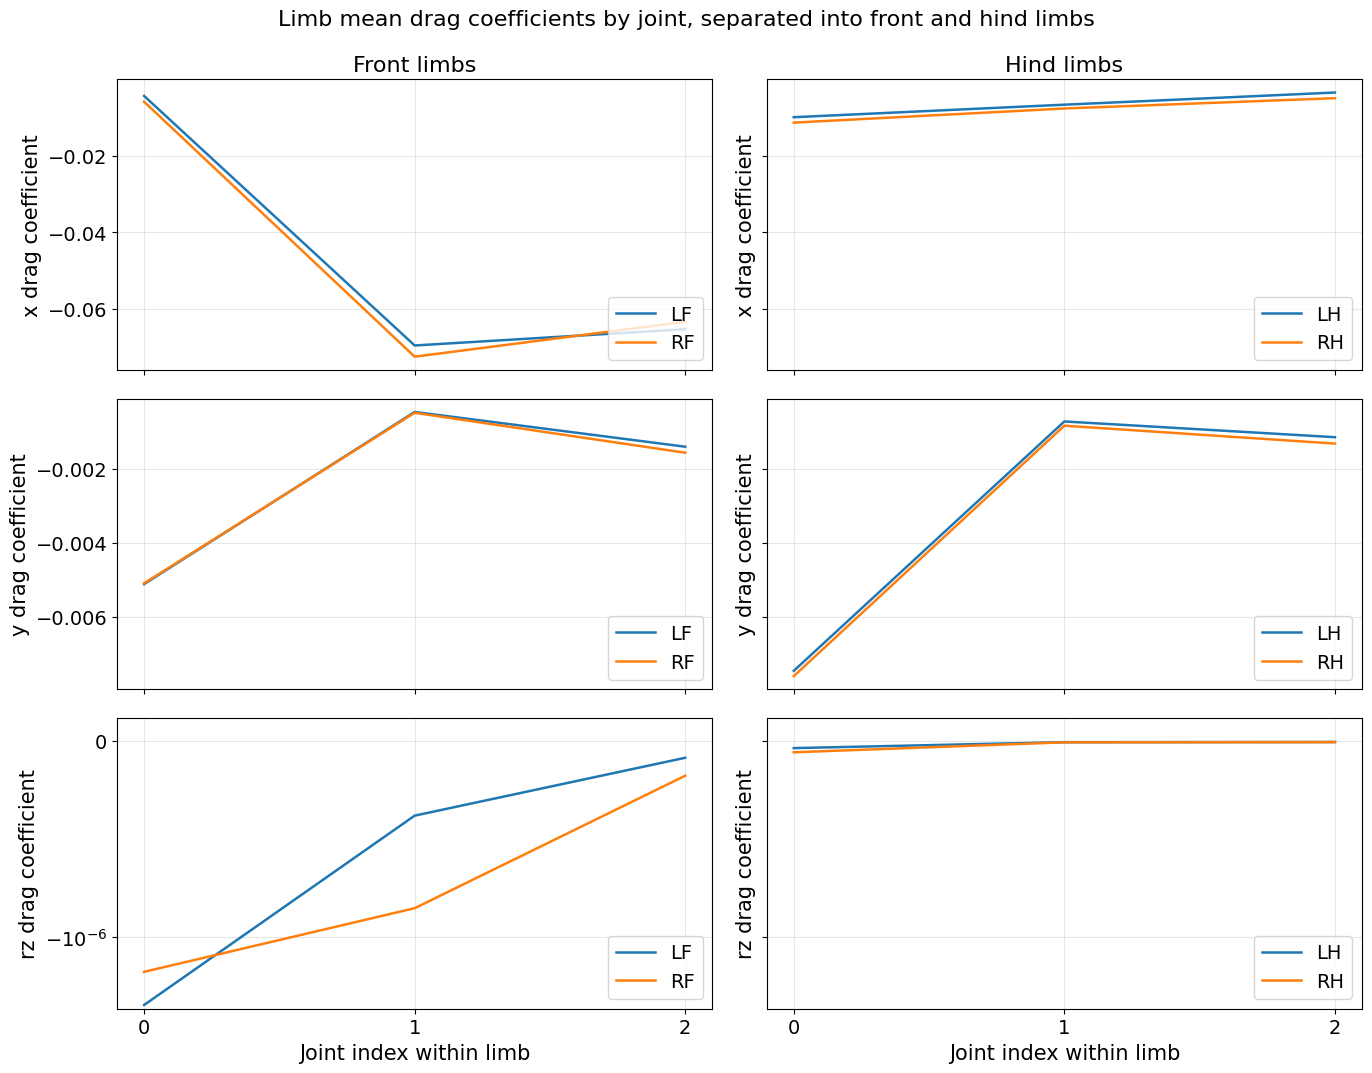

In [13]:
# Plot mean drag coefficient for the limb links, split into front and hind limbs.
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex='col', sharey='row')
limb_groups = [
    ('Front limbs', [
        ('LF', slice(0, 3)),
        ('RF', slice(3, 6)),
    ]),
    ('Hind limbs', [
        ('LH', slice(6, 9)),
        ('RH', slice(9, 12)),
    ]),
]
joint_ticks = [0, 1, 2]
joint_labels = ['0', '1', '2']
components = [
    ('x drag coefficient', limb_drag_coeff_mean_smoothed_x),
    ('y drag coefficient', limb_drag_coeff_mean_smoothed_y),
    ('rz drag coefficient', limb_drag_coeff_mean_smoothed_rz),
]

for col, (group_title, group_specs) in enumerate(limb_groups):
    for row, (ylabel, values) in enumerate(components):
        axis = axes[row, col]
        for limb_label, limb_slice in group_specs:
            joint_index = np.arange(3)
            axis.plot(joint_index, values[limb_slice], linewidth=1.8, label=limb_label)
        axis.set_xticks(joint_ticks)
        axis.set_xticklabels(joint_labels)
        axis.set_ylabel(ylabel)
        axis.grid(True, alpha=0.3)
        axis.legend(loc='lower right')
        if row == 0:
            axis.set_title(group_title)
        if row == 2:
            axis.set_xlabel('Joint index within limb')

axes[2, 0].set_yscale('symlog', linthresh=1e-6)
axes[2, 1].set_yscale('symlog', linthresh=1e-6)
fig.suptitle('Limb mean drag coefficients by joint, separated into front and hind limbs')
fig.tight_layout()


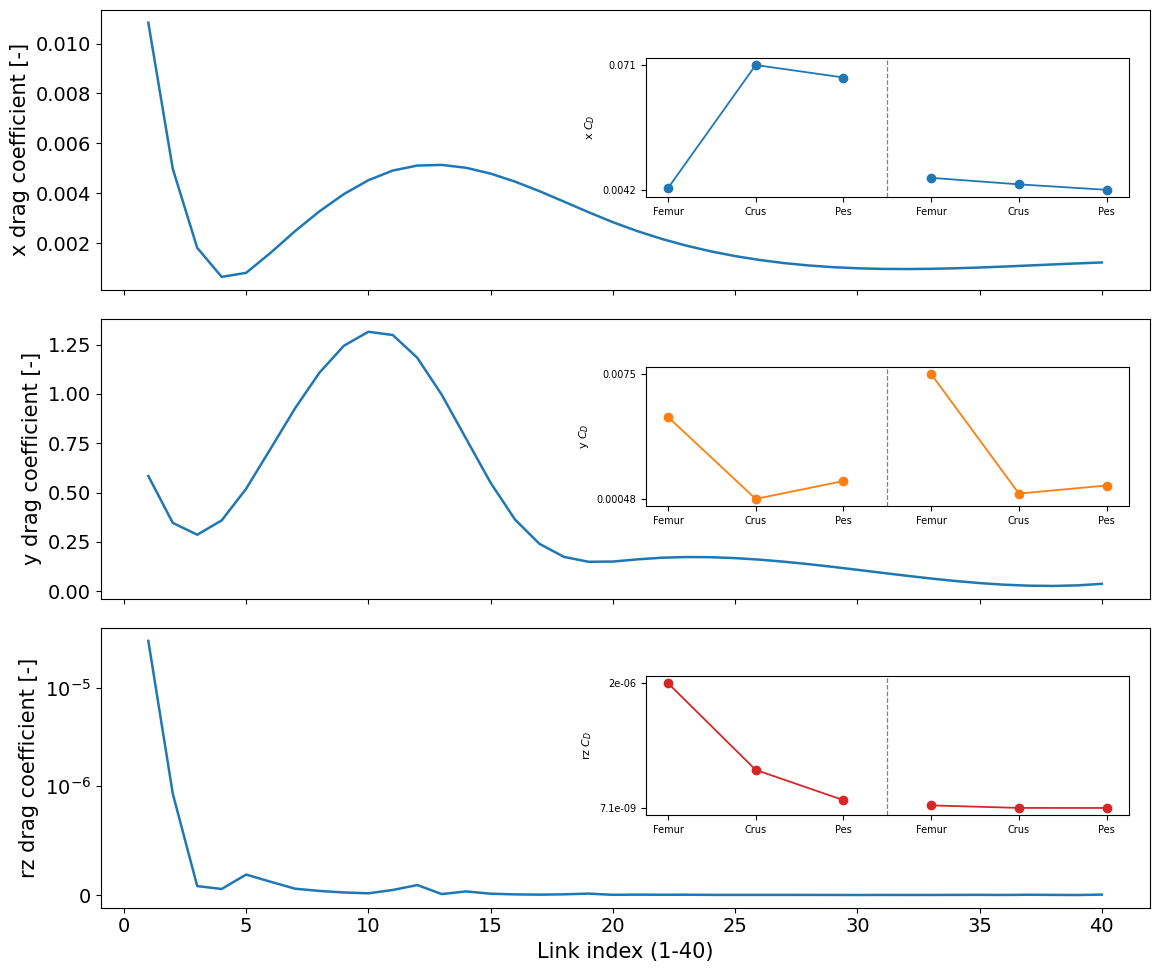

In [14]:
# Combined plot: spine profiles + limb-average insets
fig, (ax_x, ax_y, ax_rz) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Prefer smoothed profiles from Cell 9; fallback to original means if unavailable.
spine_x_source = globals().get('drag_coeff_mean_smoothed_plot_x', drag_coeff_mean_smoothed_x)
spine_y_source = globals().get('drag_coeff_mean_smoothed_plot_y', drag_coeff_mean_smoothed_y)
spine_rz_source = globals().get('drag_coeff_mean_smoothed_plot_rz', drag_coeff_mean_smoothed_rz)

# Revert sign convention for display and enforce positive values.
spine_x = np.abs(-spine_x_source)
spine_y = np.abs(-spine_y_source)
spine_rz = np.abs(-spine_rz_source)

ax_x.plot(link_ids, spine_x, linewidth=1.8, color='tab:blue')
ax_x.set_ylabel('x drag coefficient [-]')

ax_y.plot(link_ids, spine_y, linewidth=1.8, color='tab:blue')
ax_y.set_ylabel('y drag coefficient [-]')

ax_rz.plot(link_ids, spine_rz, linewidth=1.8, color='tab:blue')
ax_rz.set_ylabel('rz drag coefficient [-]')
ax_rz.set_yscale('symlog', linthresh=1e-6)
ax_rz.set_xlabel('Link index (1-40)')

# Build 6 inset points: front/hind with L-R average for each joint index.
def _avg_lr_six(values12: np.ndarray) -> np.ndarray:
    front_avg = 0.5 * (values12[0:3] + values12[3:6])
    hind_avg = 0.5 * (values12[6:9] + values12[9:12])
    return np.concatenate([front_avg, hind_avg])

inset_values_x = np.abs(-_avg_lr_six(limb_drag_coeff_mean_smoothed_x))
inset_values_y = np.abs(-_avg_lr_six(limb_drag_coeff_mean_smoothed_y))
inset_values_rz = np.abs(-_avg_lr_six(limb_drag_coeff_mean_smoothed_rz))
inset_x = np.arange(6)


def _draw_inset(parent_ax, values: np.ndarray, color: str):
    inset = parent_ax.inset_axes([0.52, 0.33, 0.46, 0.50])
    inset.plot(inset_x[0:3], values[0:3], marker='o', linewidth=1.3, color=color)
    inset.plot(inset_x[3:6], values[3:6], marker='o', linewidth=1.3, color=color)

    inset.axvline(2.5, color='0.5', linestyle='--', linewidth=0.9)
    inset.set_xticks(inset_x)
    inset.set_xticklabels(['Femur', 'Crus', 'Pes', 'Femur', 'Crus', 'Pes'], fontsize=7)
    inset.tick_params(axis='x', labelsize=7)

    finite_vals = values[np.isfinite(values)]
    if finite_vals.size > 0:
        vmin = float(np.min(finite_vals))
        vmax = float(np.max(finite_vals))
        span = vmax - vmin
        pad = 0.06 * span if span > 0 else max(1e-6, 0.1 * abs(vmin) if vmin != 0 else 1e-6)
        inset.set_ylim(vmin - pad, vmax + pad)
        inset.set_yticks([vmin, vmax])
        inset.set_yticklabels([f'{vmin:.2g}', f'{vmax:.2g}'])

    return inset


inset_x_ax = _draw_inset(ax_x, inset_values_x, 'tab:blue')
inset_x_ax.set_ylabel('x $C_D$', fontsize=8)
inset_x_ax.tick_params(axis='y', labelsize=7)

inset_y_ax = _draw_inset(ax_y, inset_values_y, 'tab:orange')
inset_y_ax.set_ylabel('y $C_D$', fontsize=8)
inset_y_ax.tick_params(axis='y', labelsize=7)

inset_rz_ax = _draw_inset(ax_rz, inset_values_rz, 'tab:red')
inset_rz_ax.set_ylabel('rz $C_D$', fontsize=8)
inset_rz_ax.tick_params(axis='y', labelsize=7)

fig.tight_layout()

## Save equivalent drag to file

In [15]:
computed_drags = np.full((52, 6), np.nan, dtype=float)

# Prefer smoothed profiles from Cell 9; fallback to original means if unavailable.
spine_export_x = globals().get('drag_coeff_mean_smoothed_plot_x', spine_x)
spine_export_y = globals().get('drag_coeff_mean_smoothed_plot_y', spine_y)
spine_export_rz = globals().get('drag_coeff_mean_smoothed_plot_rz', spine_rz)

# Spine links: first 40 entries.
computed_drags[:40, 0] = spine_export_x
computed_drags[:40, 1] = spine_export_y
computed_drags[:40, 2] = spine_export_y
computed_drags[:40, 3] = 0.0
computed_drags[:40, 4] = spine_export_rz
computed_drags[:40, 5] = spine_export_rz

# Limb links: last 12 entries.
computed_drags[40:, 0] = limb_drag_coeff_mean_smoothed_x
computed_drags[40:, 1] = limb_drag_coeff_mean_smoothed_y
computed_drags[40:, 2] = limb_drag_coeff_mean_smoothed_x
computed_drags[40:, 3] = limb_drag_coeff_mean_smoothed_rz
computed_drags[40:, 4] = 0.0
computed_drags[40:, 5] = limb_drag_coeff_mean_smoothed_rz

np.save(computed_drags_path, computed_drags)

print(f'Saved {computed_drags_path} with shape {computed_drags.shape}')

Saved drag.npy with shape (52, 6)


## Load the equivalent drag Run and compare

[ok] Freq2.5_a: baseline=Freq2.5_a (t_end=4.05s), drag=Freq2.5_adrag (t_end=4.05s), panel_xmax=4.05s
[ok] Freq3.0_a: baseline=Freq3.0_a (t_end=3.19s), drag=Freq3.0_adrag (t_end=3.19s), panel_xmax=3.19s
[ok] Freq3.5_a: baseline=Freq3.5_a (t_end=2.64s), drag=Freq3.5_adrag (t_end=2.64s), panel_xmax=2.64s
[ok] Freq4.0_a: baseline=Freq4.0_a (t_end=2.25s), drag=Freq4.0_adrag (t_end=2.25s), panel_xmax=2.25s
[ok] Freq4.5_a: baseline=Freq4.5_a (t_end=2.00s), drag=Freq4.5_adrag (t_end=2.00s), panel_xmax=2.00s
[ok] Freq5.0_a: baseline=Freq5.0_a (t_end=1.79s), drag=Freq5.0_adrag (t_end=1.79s), panel_xmax=1.79s
Plotted 6 frequency cases from /data/andreaferrario/ns_data and /data/andreaferrario/ns_data.


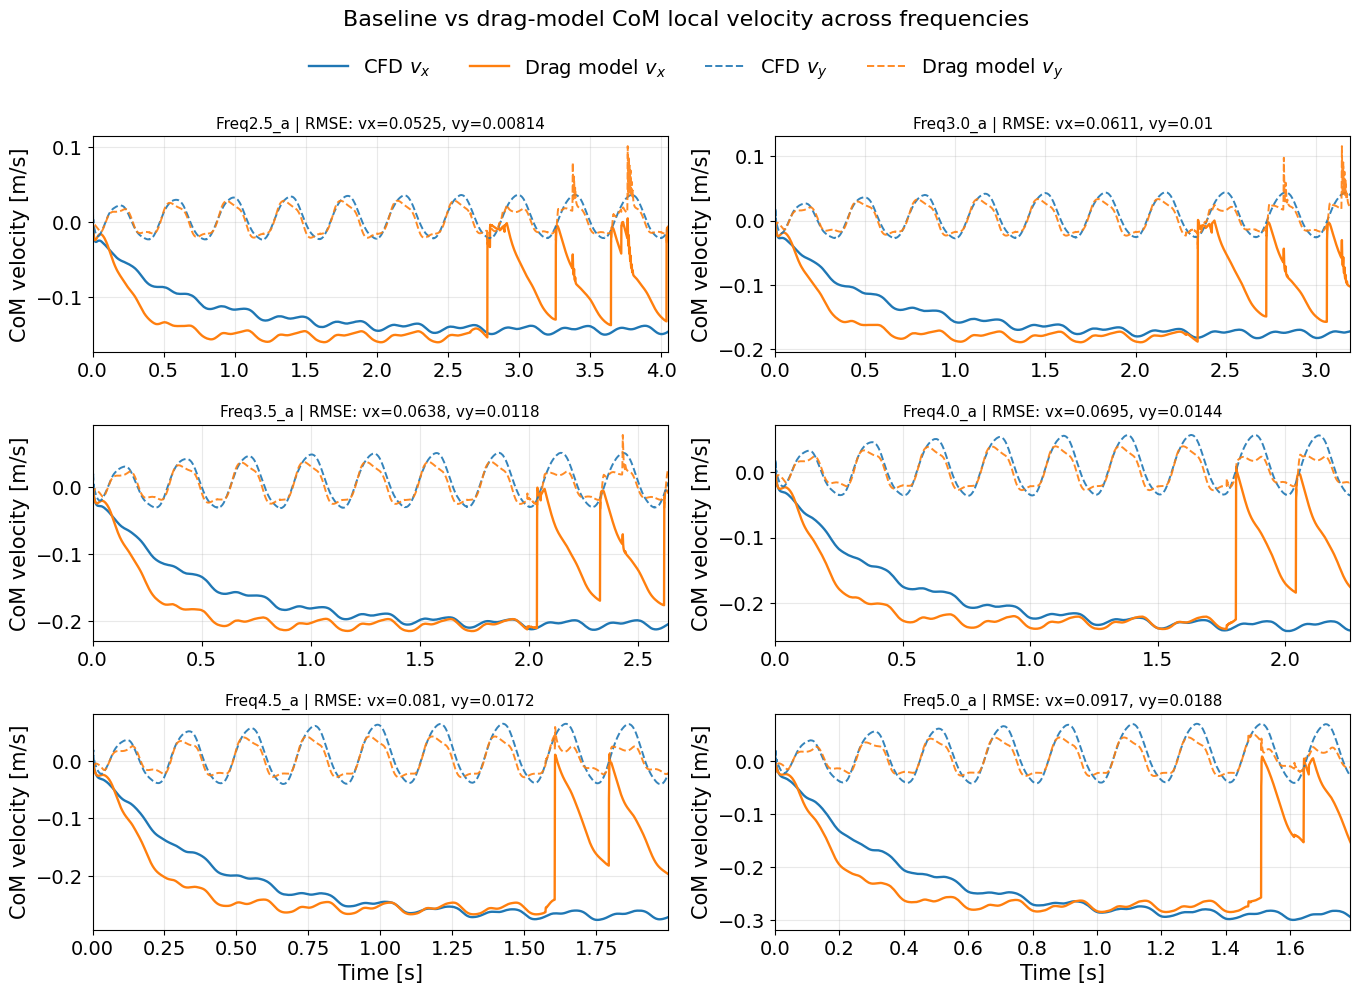

In [26]:
# Multi-frequency validation: compare baseline vs drag-model CoM local velocities
freq_values = [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
base_root = data_path.parent
drag_root = dragsim_data_path.parent

# Set to None to use full available duration per frequency pair.
clip_time_s_multi = None
results = []

for freq in freq_values:
    freq_label = f'Freq{freq:.1f}_a'
    base_dir = base_root / freq_label
    drag_dir = drag_root / f'{freq_label}drag'
    base_sim = base_dir / 'output' / 'simulation.hdf5'
    drag_sim = drag_dir / 'output' / 'simulation.hdf5'

    if not base_sim.exists() or not drag_sim.exists():
        print(f'[skip] {freq_label}: missing file(s)')
        print(f'  baseline: {base_sim} (exists={base_sim.exists()})')
        print(f'  drag    : {drag_sim} (exists={drag_sim.exists()})')
        continue

    base_t, _, base_local_xy, _ = _load_com_local_xy(base_sim)
    drag_t, _, drag_local_xy, _ = _load_com_local_xy(drag_sim)

    base_max_t = float(base_t[-1])
    drag_max_t = float(drag_t[-1])
    pair_max_t = max(base_max_t, drag_max_t)
    if clip_time_s_multi is not None:
        pair_max_t = min(pair_max_t, float(clip_time_s_multi))

    print(
        f"[ok] {freq_label}: baseline={base_dir.name} (t_end={base_max_t:.2f}s), "
        f"drag={drag_dir.name} (t_end={drag_max_t:.2f}s), panel_xmax={pair_max_t:.2f}s"
    )

    base_plot_mask = base_t <= pair_max_t
    drag_plot_mask = drag_t <= pair_max_t
    base_plot_t = base_t[base_plot_mask]
    drag_plot_t = drag_t[drag_plot_mask]
    base_plot_xy = base_local_xy[base_plot_mask]
    drag_plot_xy = drag_local_xy[drag_plot_mask]

    overlap_stop = min(base_max_t, drag_max_t, pair_max_t)
    if overlap_stop <= 0:
        print(f'[skip] {freq_label}: no overlap before clipping')
        continue

    overlap_t = base_t[base_t <= overlap_stop]
    if overlap_t.size == 0:
        print(f'[skip] {freq_label}: no overlap samples up to {overlap_stop:.2f} s')
        continue

    base_overlap_xy = np.column_stack([
        np.interp(overlap_t, base_t, base_local_xy[:, axis])
        for axis in range(2)
    ])
    drag_overlap_xy = np.column_stack([
        np.interp(overlap_t, drag_t, drag_local_xy[:, axis])
        for axis in range(2)
    ])

    rmse_vx = float(np.sqrt(np.nanmean((drag_overlap_xy[:, 0] - base_overlap_xy[:, 0]) ** 2)))
    rmse_vy = float(np.sqrt(np.nanmean((drag_overlap_xy[:, 1] - base_overlap_xy[:, 1]) ** 2)))

    results.append({
        'freq': freq,
        'label': freq_label,
        'base_t': base_plot_t,
        'drag_t': drag_plot_t,
        'base_local_xy': base_plot_xy,
        'drag_local_xy': drag_plot_xy,
        'xmax': pair_max_t,
        'rmse_vx': rmse_vx,
        'rmse_vy': rmse_vy,
    })

if not results:
    raise ValueError('No valid frequency pairs found between baseline and drag-model folders.')

n_panels = len(results)
ncols = 2
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), sharex=False)
axes = np.atleast_1d(axes).reshape(nrows, ncols)

for idx, entry in enumerate(results):
    ax = axes[idx // ncols, idx % ncols]
    base_t_plot = entry['base_t']
    drag_t_plot = entry['drag_t']
    base_xy = entry['base_local_xy']
    drag_xy = entry['drag_local_xy']

    ax.plot(base_t_plot, base_xy[:, 0], color='tab:blue', linewidth=1.7, label='CFD $v_x$')
    ax.plot(drag_t_plot, drag_xy[:, 0], color='tab:orange', linewidth=1.7, label='Drag model $v_x$')
    ax.plot(base_t_plot, base_xy[:, 1], color='tab:blue', linestyle='--', linewidth=1.4, alpha=0.9, label='CFD $v_y$')
    ax.plot(drag_t_plot, drag_xy[:, 1], color='tab:orange', linestyle='--', linewidth=1.4, alpha=0.9, label='Drag model $v_y$')

    ax.set_xlim(0.0, entry['xmax'])
    ax.set_title(
        f"{entry['label']} | RMSE: vx={entry['rmse_vx']:.3g}, vy={entry['rmse_vy']:.3g}",
        fontsize=11,
    )
    ax.set_ylabel('CoM velocity [m/s]')
    ax.grid(True, alpha=0.28)

# Hide any unused axes.
for idx in range(n_panels, nrows * ncols):
    axes[idx // ncols, idx % ncols].axis('off')

for ax in axes[-1, :]:
    if ax.has_data():
        ax.set_xlabel('Time [s]')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.01), frameon=False)
fig.suptitle('Baseline vs drag-model CoM local velocity across frequencies', y=1.04)
fig.tight_layout()

print(f'Plotted {n_panels} frequency cases from {base_root} and {drag_root}.')

In [142]:
# Multi-frequency validation: compare baseline vs drag-model CoM local velocities
freq_values = [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
base_root = data_path.parent
drag_root = dragsim_data_path.parent

clip_time_s_multi = 1.5
results = []

for freq in freq_values:
    freq_label = f'Freq{freq:.1f}'
    base_dir = base_root / freq_label
    drag_dir = drag_root / f'{freq_label}_adrag'
    base_sim = base_dir / 'output' / 'simulation.hdf5'
    drag_sim = drag_dir / 'output' / 'simulation.hdf5'

    if not base_sim.exists() or not drag_sim.exists():
        print(f'[skip] {freq_label}: missing file(s)')
        print(f'  baseline: {base_sim} (exists={base_sim.exists()})')
        print(f'  drag    : {drag_sim} (exists={drag_sim.exists()})')
        continue

    print(f'[ok] {freq_label}: baseline={base_dir.name}, drag={drag_dir.name}')

    base_t, _, base_local_xy, _ = _load_com_local_xy(base_sim)
    drag_t, _, drag_local_xy, _ = _load_com_local_xy(drag_sim)

    common_stop = min(base_t[-1], drag_t[-1])
    common_t = base_t[base_t <= common_stop]
    if common_t.size == 0:
        print(f'[skip] {freq_label}: no overlap before clipping')
        continue

    if clip_time_s_multi is not None:
        clip_mask = common_t <= float(clip_time_s_multi)
        common_t = common_t[clip_mask]
    if common_t.size == 0:
        print(f'[skip] {freq_label}: no samples up to {clip_time_s_multi:.2f} s')
        continue

    base_local_interp = np.column_stack([
        np.interp(common_t, base_t, base_local_xy[:, axis])
        for axis in range(2)
    ])
    drag_local_interp = np.column_stack([
        np.interp(common_t, drag_t, drag_local_xy[:, axis])
        for axis in range(2)
    ])

    rmse_vx = float(np.sqrt(np.nanmean((drag_local_interp[:, 0] - base_local_interp[:, 0]) ** 2)))
    rmse_vy = float(np.sqrt(np.nanmean((drag_local_interp[:, 1] - base_local_interp[:, 1]) ** 2)))

    results.append({
        'freq': freq,
        'label': freq_label,
        't': common_t,
        'base_local_xy': base_local_interp,
        'drag_local_xy': drag_local_interp,
        'rmse_vx': rmse_vx,
        'rmse_vy': rmse_vy,
    })

if not results:
    raise ValueError('No valid frequency pairs found between baseline and drag-model folders.')

n_panels = len(results)
ncols = 2
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), sharex=True)
axes = np.atleast_1d(axes).reshape(nrows, ncols)

for idx, entry in enumerate(results):
    ax = axes[idx // ncols, idx % ncols]
    t = entry['t']
    base_xy = entry['base_local_xy']
    drag_xy = entry['drag_local_xy']

    ax.plot(t, base_xy[:, 0], color='tab:blue', linewidth=1.7, label='CFD $v_x$')
    ax.plot(t, drag_xy[:, 0], color='tab:orange', linewidth=1.7, label='Drag model $v_x$')
    ax.plot(t, base_xy[:, 1], color='tab:blue', linestyle='--', linewidth=1.4, alpha=0.9, label='CFD $v_y$')
    ax.plot(t, drag_xy[:, 1], color='tab:orange', linestyle='--', linewidth=1.4, alpha=0.9, label='Drag model $v_y$')

    ax.set_title(
        f"{entry['label']} | RMSE: vx={entry['rmse_vx']:.3g}, vy={entry['rmse_vy']:.3g}",
        fontsize=11,
    )
    ax.set_ylabel('CoM velocity [m/s]')
    ax.grid(True, alpha=0.28)

# Hide any unused axes.
for idx in range(n_panels, nrows * ncols):
    axes[idx // ncols, idx % ncols].axis('off')

for ax in axes[-1, :]:
    if ax.has_data():
        ax.set_xlabel('Time [s]')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.01), frameon=False)
fig.suptitle('Baseline vs drag-model CoM local velocity across frequencies', y=1.04)
fig.tight_layout()

print(f'Plotted {n_panels} frequency cases from {base_root} and {drag_root}.')

[skip] Freq2.5: missing file(s)
  baseline: /data/andreaferrario/ns_data/Freq2.5/output/simulation.hdf5 (exists=False)
  drag    : /data/andreaferrario/ns_data/Freq2.5_adrag/output/simulation.hdf5 (exists=True)
[skip] Freq3.0: missing file(s)
  baseline: /data/andreaferrario/ns_data/Freq3.0/output/simulation.hdf5 (exists=False)
  drag    : /data/andreaferrario/ns_data/Freq3.0_adrag/output/simulation.hdf5 (exists=True)
[skip] Freq3.5: missing file(s)
  baseline: /data/andreaferrario/ns_data/Freq3.5/output/simulation.hdf5 (exists=False)
  drag    : /data/andreaferrario/ns_data/Freq3.5_adrag/output/simulation.hdf5 (exists=True)
[skip] Freq4.0: missing file(s)
  baseline: /data/andreaferrario/ns_data/Freq4.0/output/simulation.hdf5 (exists=False)
  drag    : /data/andreaferrario/ns_data/Freq4.0_adrag/output/simulation.hdf5 (exists=True)
[skip] Freq4.5: missing file(s)
  baseline: /data/andreaferrario/ns_data/Freq4.5/output/simulation.hdf5 (exists=False)
  drag    : /data/andreaferrario/ns_d

ValueError: No valid frequency pairs found between baseline and drag-model folders.

Reference: Freq4.5, ref_steps=4000, target_dx=0.426364 m

Suggested step counts to match reference x-travel:
freq [Hz] | dt [s]     | available_steps | dx_total [m] | dx/step [m] | suggested_steps | sim_time [s]
     2.5 |     0.0005 |            4000 |    0.210601 | 5.26503e-05 |            8098 |      4.049
     3.0 |     0.0005 |            4000 |    0.267085 | 6.67713e-05 |            6385 |     3.1925
     3.5 |     0.0005 |            4000 |    0.323397 | 8.08493e-05 |            5274 |      2.637
     4.0 |     0.0005 |            4000 |    0.378046 | 9.45114e-05 |            4511 |     2.2555
     4.5 |     0.0005 |            3500 |    0.373068 | 0.000106591 |            4000 |          2
     5.0 |     0.0005 |            4000 |     0.47707 | 0.000119268 |            3575 |     1.7875


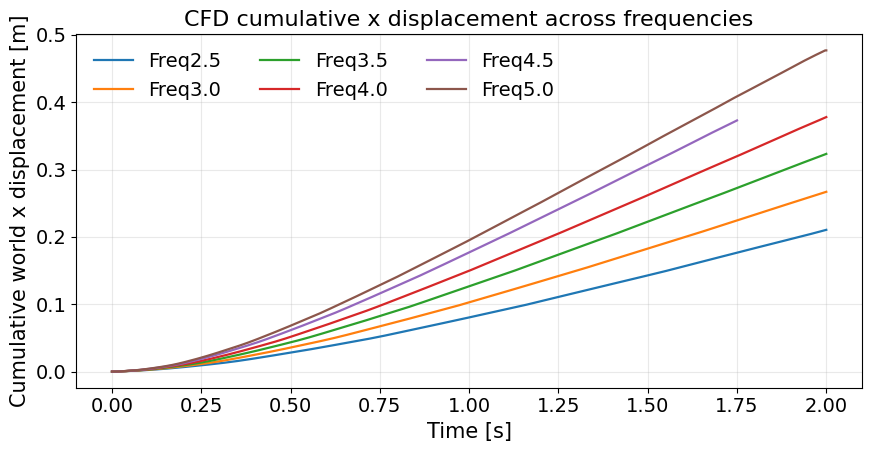

In [125]:
# Step-count tuning by matched CFD travel distance along world x
freq_values = [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
base_root = data_path.parent
ref_freq = 4.5
ref_steps = 4000

def _integrate_x(times: np.ndarray, vx: np.ndarray) -> np.ndarray:
    x = np.zeros_like(vx, dtype=float)
    if times.size > 1:
        dt = np.diff(times)
        x[1:] = np.cumsum(0.5 * (vx[1:] + vx[:-1]) * dt)
    return x

rows = []
for freq in freq_values:
    sim_path_f = base_root / f"Freq{freq:.1f}" / "output" / "simulation.hdf5"
    if not sim_path_f.exists():
        print(f"[skip] missing: {sim_path_f}")
        continue

    t_f, world_xy_f, _, dt_f = _load_com_local_xy(sim_path_f)
    if t_f.size < 2:
        print(f"[skip] too short: Freq{freq:.1f}")
        continue

    x_world_f = _integrate_x(t_f, world_xy_f[:, 0])
    dx_total = float(x_world_f[-1] - x_world_f[0])
    n_steps_available = int(t_f.size - 1)
    dx_per_step = dx_total / n_steps_available if n_steps_available > 0 else np.nan
    rows.append((freq, dt_f, n_steps_available, dx_total, dx_per_step))

if not rows:
    raise ValueError("No CFD frequency runs found.")

distance_table = np.array(rows, dtype=float)
freq_col = distance_table[:, 0]
dt_col = distance_table[:, 1]
steps_col = distance_table[:, 2]
dx_col = distance_table[:, 3]
dxps_col = distance_table[:, 4]

ref_mask = np.isclose(freq_col, ref_freq)
if not np.any(ref_mask):
    raise ValueError(f"Reference frequency {ref_freq} not found in CFD runs.")

dxps_ref = float(dxps_col[ref_mask][0])
target_dx = dxps_ref * ref_steps

suggested_steps = np.round(target_dx / dxps_col).astype(int)
suggested_steps = np.maximum(suggested_steps, 1)
sim_time_s = suggested_steps * dt_col

print(f"Reference: Freq{ref_freq:.1f}, ref_steps={ref_steps}, target_dx={target_dx:.6g} m")
print("\nSuggested step counts to match reference x-travel:")
print("freq [Hz] | dt [s]     | available_steps | dx_total [m] | dx/step [m] | suggested_steps | sim_time [s]")
for i in range(freq_col.size):
    print(
        f"{freq_col[i]:8.1f} | {dt_col[i]:10.6g} | {int(steps_col[i]):15d} | "
        f"{dx_col[i]:11.6g} | {dxps_col[i]:10.6g} | {int(suggested_steps[i]):15d} | {sim_time_s[i]:10.6g}"
    )

# Optional: plot cumulative x displacement for visual check.
fig, ax = plt.subplots(figsize=(9, 4.8))
for freq in freq_values:
    sim_path_f = base_root / f"Freq{freq:.1f}" / "output" / "simulation.hdf5"
    if not sim_path_f.exists():
        continue
    t_f, world_xy_f, _, _ = _load_com_local_xy(sim_path_f)
    x_world_f = _integrate_x(t_f, world_xy_f[:, 0])
    ax.plot(t_f, x_world_f, linewidth=1.6, label=f"Freq{freq:.1f}")

ax.set_xlabel("Time [s]")
ax.set_ylabel("Cumulative world x displacement [m]")
ax.set_title("CFD cumulative x displacement across frequencies")
ax.grid(True, alpha=0.28)
ax.legend(ncol=3, frameon=False)
fig.tight_layout()